# Wide Receiver Route Classification
#### Parker Loupessis

 https://github.com/parloups/csci0451-loupessis-finalproject.git

**this is a *rough* draft** 

and very much not fully completed. However, I would greatly appreciate any feedback you can give me on what is here! 

My biggest question is if it's okay that the sections you had lined out on the course website kind of mix. Right now, I have things you put under approach in my data section, and then my approach and results mixed together from that as well. Also, since I worked on my own, do I need a Group Contributions Statement?

In [1]:
import pandas as pd
import torch
from matplotlib import pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

## Abstract
This project attempted to classify wide receiver routes based on their (x,y) coordinates, speed, and direction throughout the play. The models used were all GRU RNNs with two layers and 64 hidden states. The first model used the (x, y) coordinates of the WR throughout the play and the snap location with the targets as basic route labels (go, in, out, curl), and acheived 60% accuracy on test data. The second model added WR's speed and direction, achieving 70% accuracy on test data. The third model used relative coordinates of the WR to the snap and augmented data, achieving 80% accuracy on test data. The fourth and final model used the same features as the third, but the targets were the "true" route labels (post, slant, dig, ...) and achieved 45% accuracy on test data.

## Introduction
Football teams, at all levels, spend lots of time breaking down film to gather statistics which help diagnose tendencies and lead to a better understanding of opponesnts and themselves. This project aims to take a first step towards speeding up that long process, so that more time can be spent on analyzing the results.

The NFL has turned into a passing league, in which almost all offenses call more passing plays than running plays. These passing plays have each WR run a specific route. By labeling the route each of them ran, we could then expand upon this to label the play that was called. This would mean nearly cutting the time spent breaking down film in half (as there are still other important parts to passing plays). It would also be a proof of concept—providing evidence that something like this could be done.

(need lit review)

## Values Statement
coaches and assistants are users

players affected by better help from coaches, fans as this could make data like this more available 

they all benefit

low level assistants in which this is mostly their entire job could be affected

really interested in football

the world would be about the same

This would help coaches, scouts, and assistants a lot, as breaking down a game is time-consuming (and most don’t find it that fun). Anyone working in the football sphere has the potential to benefit from this because they could spend more time actually analyzing the film and the stats, not just prepping to do so. Some of these same people could also be harmed by it, as it could mean less of a demand for lower-ranked coaches, scouts, or assistants. Then, if fewer are needed, it makes it harder for someone to break into the field and work their way up the ranks. The world will probably be about the same after this project because it will only affect/help a relatively small subset of people, and while it will likely help the jobs of some, it might also keep others from getting jobs.

## Data

In the NFL, every player has a chip in their shoulder pads that tracks their position on the field throughout the game. We can then define the field as an x-y plane, and give the coordinates of each player. We can also calculate things like their speed and direction from this data. The data used for this project is a subset of the data from the 2019 NFL Big Data Bowl. Every year since 2019, the NFL has hosted a Big Data Bowl, in which it makes this tracking data public for fans and data scientists to develop statistical insights on a proposed question. The GitHub Repository from the 2019 challenge is still public and contains all of the game, play, and player-level data. However, only one game of tracking data remains.

To filter the data to only include what was needed for the model, the script `filter_data` was used to create the `track_WR_clean` dataframe. In that, the game, play, and player data were merged with the tracking data using key variables. Then it was filtered to only include WRs on true passing plays, and only include the timepoints of the route (from the time the ball was snapped until the pass arrived).

In [2]:
url1 = "https://raw.githubusercontent.com/parloups/csci0451-loupessis-finalproject/refs/heads/main/data/track_WR_clean.csv"
track_WR_clean = pd.read_csv(url1)
track_WR_clean.head()

,x,y,s,dis,dir,event,nflId,displayName,jerseyNumber,team,...,yardlineNumber,isSTPlay,PassLength,PassResult,YardsAfterCatch,PlayResult,playDescription,PositionAbbr,snap_x,snap_y
0,84.61,19.36,1.75,0.00,266.27,ball_snap,2530515.0,Chris Hogan,15.0,home,...,27.0,False,27.0,I,NaN,0,(14:55) NE 12-Brady 18th season as Patriots QB...,WR,82.87,29.8
1,84.60,19.36,2.06,0.01,266.05,NaN,2530515.0,Chris Hogan,15.0,home,...,27.0,False,27.0,I,NaN,0,(14:55) NE 12-Brady 18th season as Patriots QB...,WR,82.87,29.8
2,84.59,19.36,2.39,0.02,265.65,NaN,2530515.0,Chris Hogan,15.0,home,...,27.0,False,27.0,I,NaN,0,(14:55) NE 12-Brady 18th season as Patriots QB...,WR,82.87,29.8
3,84.50,19.36,2.73,0.08,265.45,NaN,2530515.0,Chris Hogan,15.0,home,...,27.0,False,27.0,I,NaN,0,(14:55) NE 12-Brady 18th season as Patriots QB...,WR,82.87,29.8
4,84.20,19.34,3.11,0.30,265.46,NaN,2530515.0,Chris Hogan,15.0,home,...,27.0,False,27.0,I,NaN,0,(14:55) NE 12-Brady 18th season as Patriots QB...,WR,82.87,29.8


Through this data cleaning, a specific play went from looking like this:

In [3]:
from IPython.display import Video
Video("visualizations/full_play.mp4")

To looking like this:

In [4]:
from IPython.display import Video
Video("visualizations/wr_only.mp4")

The columns in this dataset that were used as feature to train the models were:

*   `x`: WR position from endzone to endzone (0 - 120)
*   `y`: WR position from sideline to sideline (0 - 53.3)
*   `snap_x`: snap position from endzone to endzone (0 - 120)
*   `snap_y`: snap position from sideline to sideline (0 - 53.3)
*   `s`: WR speed in yards/second (0 <)
*   `dis`: WR distance traveled from previous frame, in yards (0 <)
*   `dir`: WR angle of motion (0 - 360)

Columns later created in `PadRoutes` that were also used as features in training were:
*   `relative_x` and `relative_y`: relative WR postion to the snap postion
*   `dir_sin` and `dir_cos`: to make `dir` continous

Unfortunately, this dataset did not contain any information about the routes the WRs ran. That meant that the target columns needed to be created entirely from scratch. To do so, I found the broadcast footage of the game and watched it to manually input two sets of labels into a dataframe.

In [5]:
url2 = "https://raw.githubusercontent.com/parloups/csci0451-loupessis-finalproject/refs/heads/main/data/route_lables_only.csv"
labels_only = pd.read_csv(url2)
labels_only.head()

,Label1,Label2,nflId,frame.id,playId
0,In,Post,2530515.0,15,68
1,In,Post,2530515.0,16,68
2,In,Post,2530515.0,17,68
3,In,Post,2530515.0,18,68
4,In,Post,2530515.0,19,68


The first set of labels (`Label1`) was the "basic" route label, which essentially meant did the WR go deep (Go), did they break in (In), did they break out (Out), or did they stop (Curl). The second set (`Label2`) was the "true" route label (post, slant, dig, ...), which may vary person to person, but the final say was at my discretion.

These two datasets were then used in the scrpits `prep_label1` and `prep_label2` along with the `PadRoutes` function to create the torch tensors used for model training. 

In [6]:
data1 = torch.load("data/tensors.pt")
X_train1 = data1["X_train"]
X_test1 = data1["X_test"]
y_train1 = data1["y_train"]
y_test1 = data1["y_test"]

X_train1 = X_train1.to(torch.float32)
X_test1 = X_test1.to(torch.float32)
y_train1 = y_train1.to(torch.long)
y_test1 = y_test1.to(torch.long)

data2 = torch.load("data/tensors2.pt")
X_train2 = data2["X_train"]
X_test2 = data2["X_test"]
y_train2 = data2["y_train"]
y_test2 = data2["y_test"]

X_train2 = X_train2.to(torch.float32)
X_test2 = X_test2.to(torch.float32)
y_train2 = y_train2.to(torch.long)
y_test2 = y_test2.to(torch.long)

## Approach and Results
GRU models, talk all about them

first model had these features and targets

We ran cross validaiton to see performance

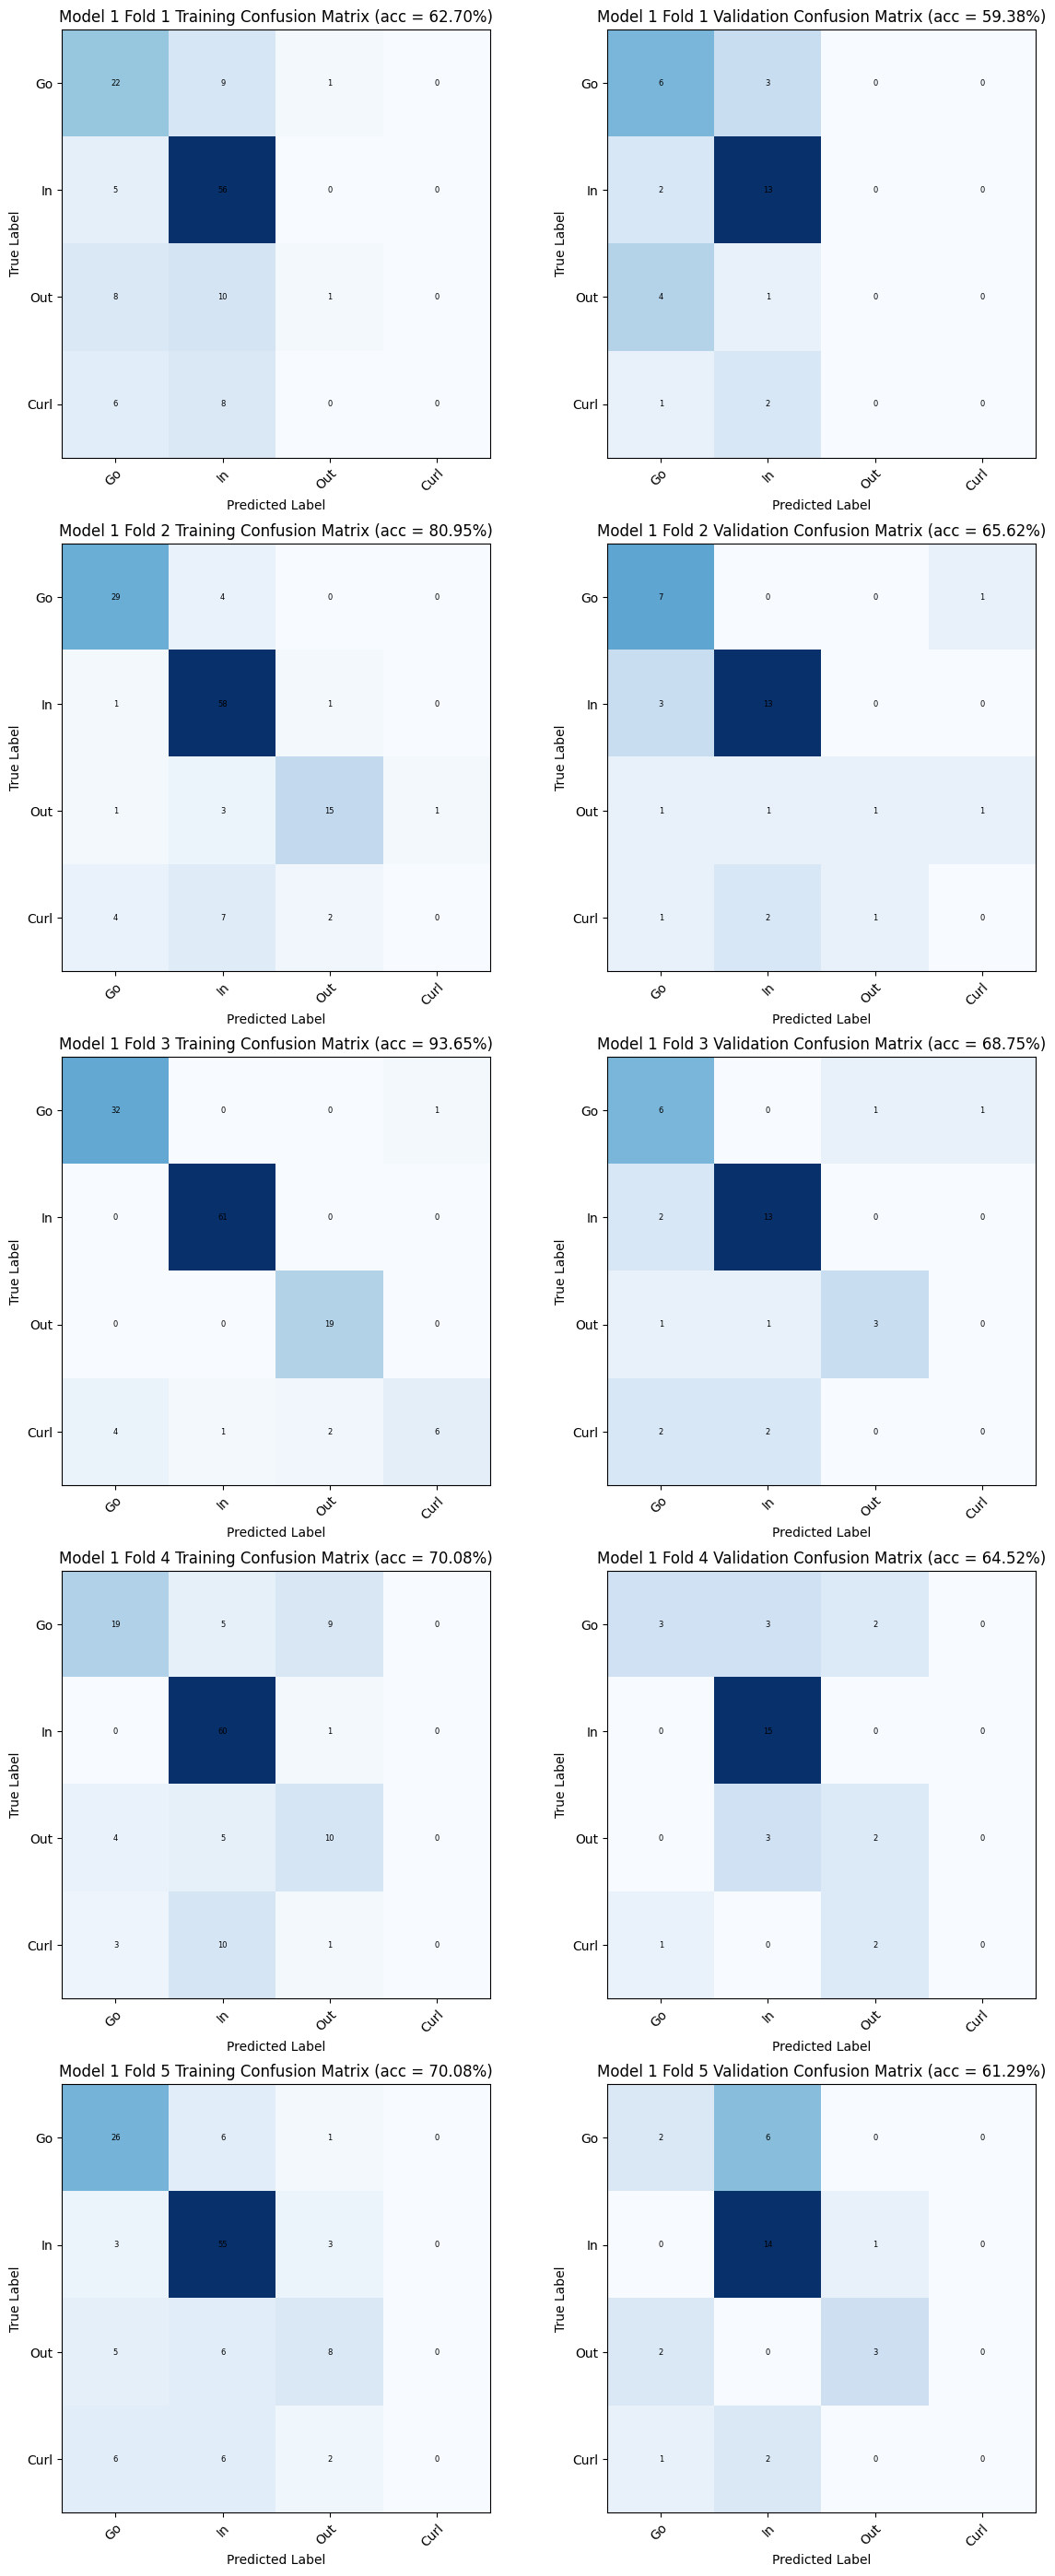

In [17]:
from src.TrainEval import TrainEval
from src.RouteClassifier1 import RouteClassifier1
model1_cv_results = torch.load("models/model1_cv_results.pt")
train_acc  = model1_cv_results["train_acc"]
train_loss = model1_cv_results["train_loss"]
train_cm   = model1_cv_results["train_cm"]
val_acc    = model1_cv_results["val_acc"]
val_loss   = model1_cv_results["val_loss"]
val_cm     = model1_cv_results["val_cm"]

model1 = RouteClassifier1()
TrainEval1 = TrainEval(model1, second_labels=False)

fig, axarr = plt.subplots(5, 2, figsize = (14, 35))
ax = axarr[0][0]
TrainEval1.plot_confusion_mat(train_cm[0], ax, title = f"Model 1 Fold 1 Training Confusion Matrix (acc = {train_acc[0]:.2%})")
ax = axarr[0][1]
TrainEval1.plot_confusion_mat(val_cm[0], ax, title = f"Model 1 Fold 1 Validation Confusion Matrix (acc = {val_acc[0]:.2%})")

ax = axarr[1][0]
TrainEval1.plot_confusion_mat(train_cm[1], ax, title = f"Model 1 Fold 2 Training Confusion Matrix (acc = {train_acc[1]:.2%})")
ax = axarr[1][1]
TrainEval1.plot_confusion_mat(val_cm[1], ax, title = f"Model 1 Fold 2 Validation Confusion Matrix (acc = {val_acc[1]:.2%})")

ax = axarr[2][0]
TrainEval1.plot_confusion_mat(train_cm[2], ax, title = f"Model 1 Fold 3 Training Confusion Matrix (acc = {train_acc[2]:.2%})")
ax = axarr[2][1]
TrainEval1.plot_confusion_mat(val_cm[2], ax, title = f"Model 1 Fold 3 Validation Confusion Matrix (acc = {val_acc[2]:.2%})")

ax = axarr[3][0]
TrainEval1.plot_confusion_mat(train_cm[3], ax, title = f"Model 1 Fold 4 Training Confusion Matrix (acc = {train_acc[3]:.2%})")
ax = axarr[3][1]
TrainEval1.plot_confusion_mat(val_cm[3], ax, title = f"Model 1 Fold 4 Validation Confusion Matrix (acc = {val_acc[3]:.2%})")

ax = axarr[4][0]
TrainEval1.plot_confusion_mat(train_cm[4], ax, title = f"Model 1 Fold 5 Training Confusion Matrix (acc = {train_acc[4]:.2%})")
ax = axarr[4][1]
TrainEval1.plot_confusion_mat(val_cm[4], ax, title = f"Model 1 Fold 5 Validation Confusion Matrix (acc = {val_acc[4]:.2%})")

Then ran on test data

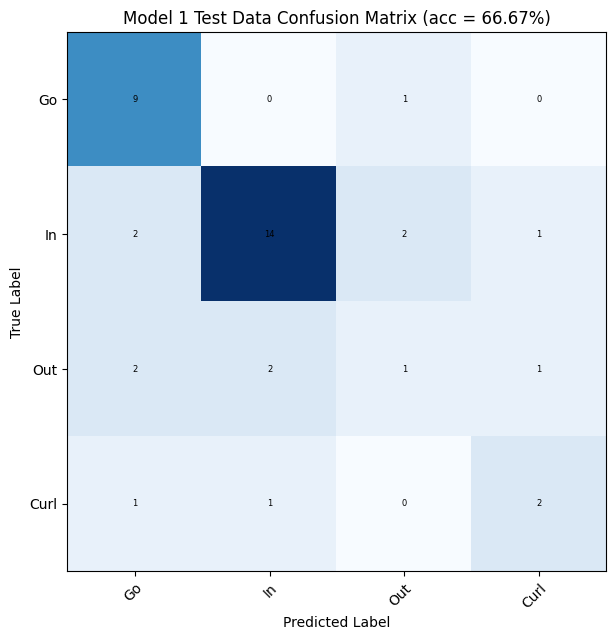

In [18]:
model1.load_state_dict(torch.load("models/model1.pt"))
model1.eval()

test_set = TensorDataset(X_test1, y_test1)
test_loader = DataLoader(test_set, batch_size=8, shuffle=False)

test_acc, test_loss, test_cm = TrainEval1.evaluate(model1, test_loader)

fig, ax = plt.subplots(1, 1, figsize = (14, 7))
TrainEval1.plot_confusion_mat(test_cm, ax, title = f"Model 1 Test Data Confusion Matrix (acc = {test_acc:.2%})")

model 2 had these features and targets

ran cv

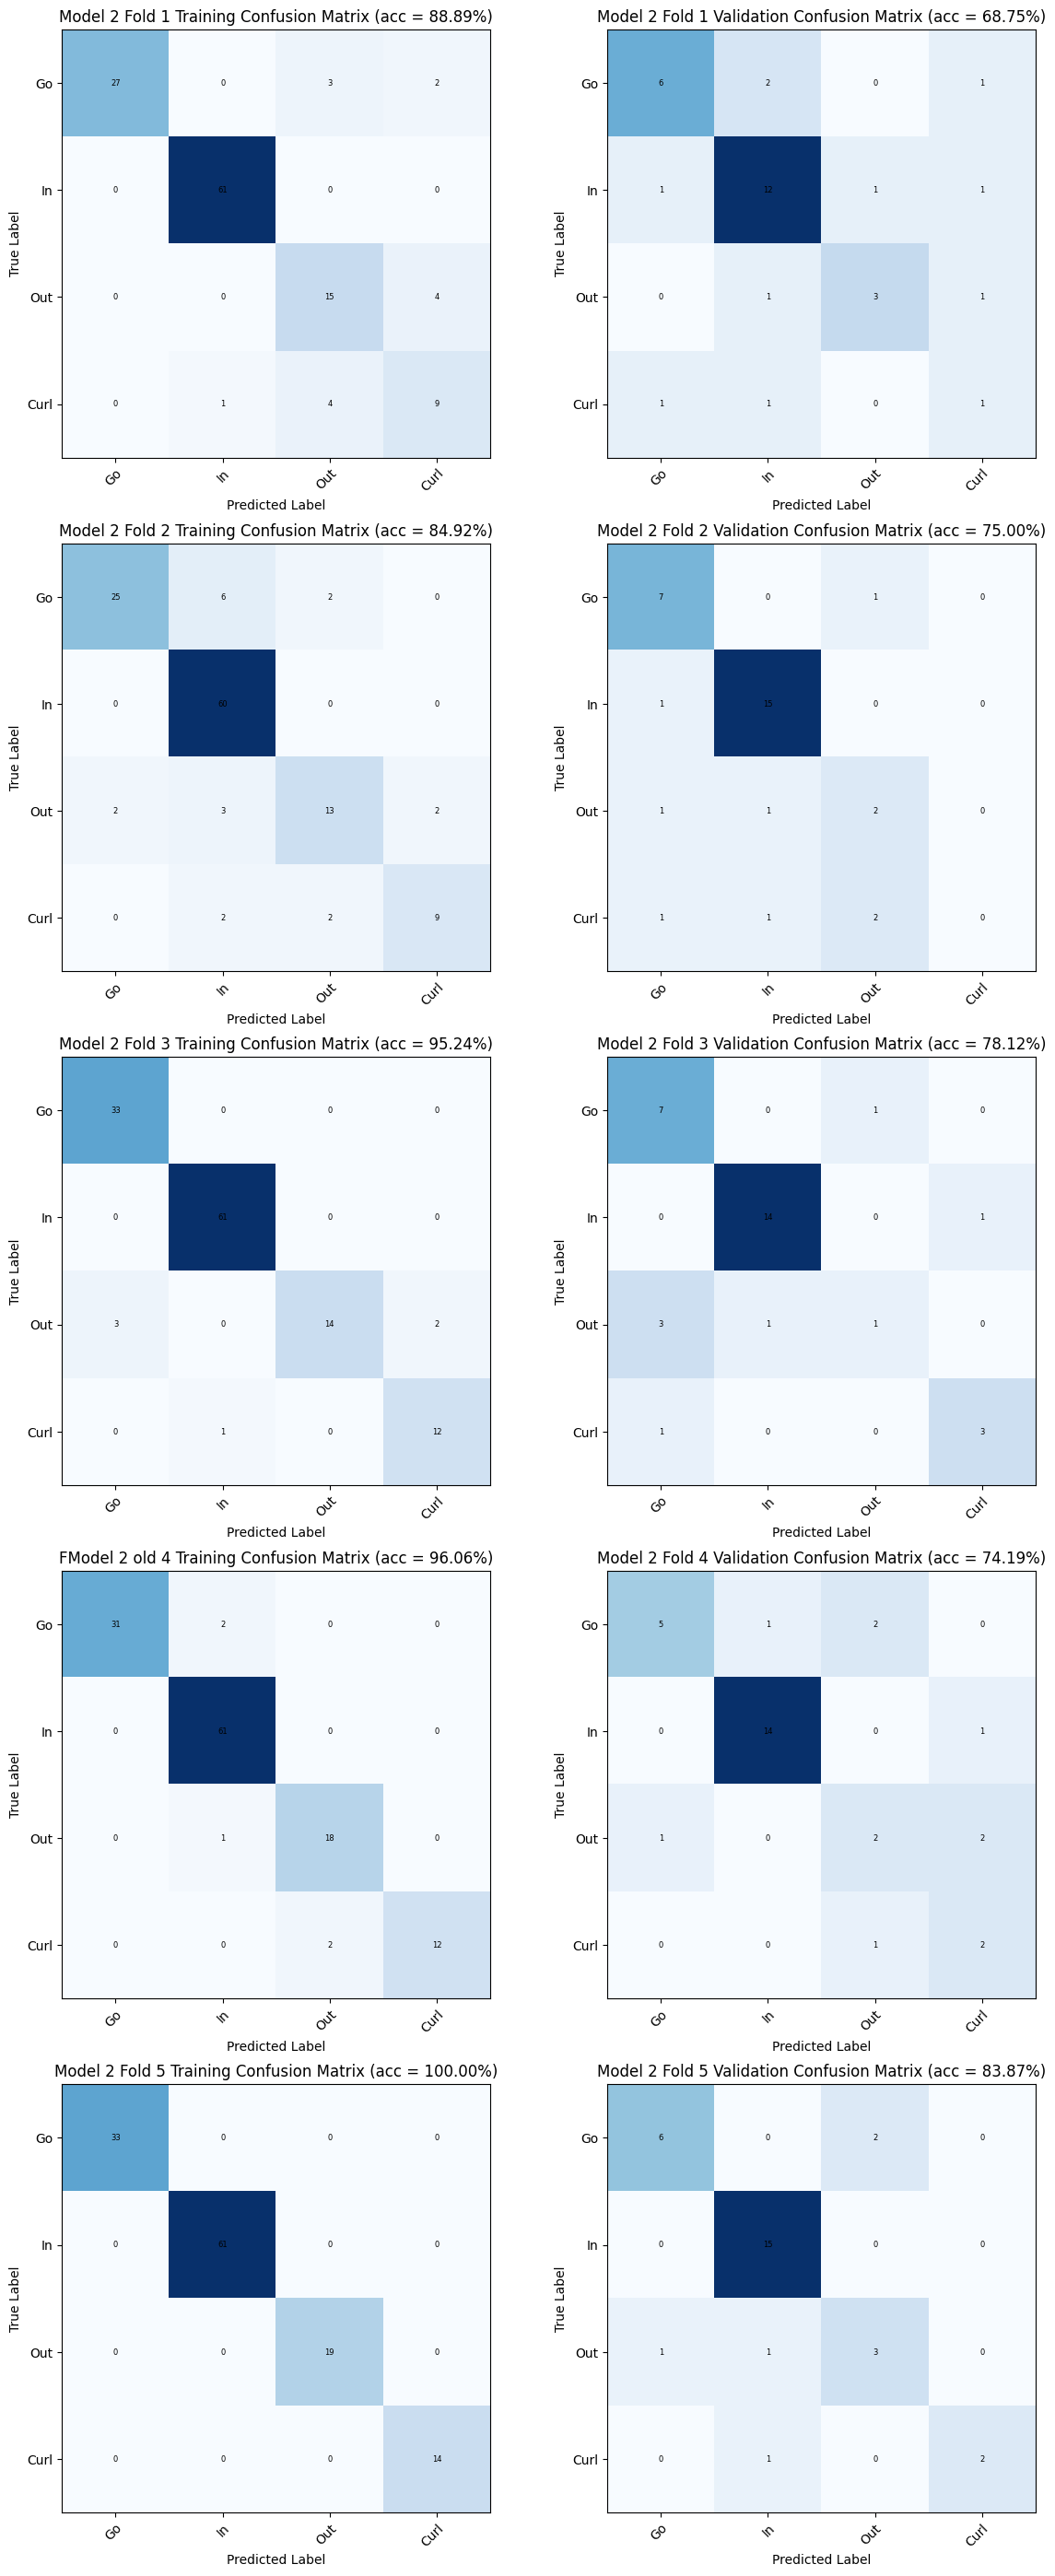

In [19]:
from src.RouteClassifier2 import RouteClassifier2
model2_cv_results = torch.load("models/model2_cv_results.pt")
train_acc  = model2_cv_results["train_acc"]
train_loss = model2_cv_results["train_loss"]
train_cm   = model2_cv_results["train_cm"]
val_acc    = model2_cv_results["val_acc"]
val_loss   = model2_cv_results["val_loss"]
val_cm     = model2_cv_results["val_cm"]

model2 = RouteClassifier2()
TrainEval2 = TrainEval(model2, second_labels=False)

fig, axarr = plt.subplots(5, 2, figsize = (14, 35))
ax = axarr[0][0]
TrainEval2.plot_confusion_mat(train_cm[0], ax, title = f"Model 2 Fold 1 Training Confusion Matrix (acc = {train_acc[0]:.2%})")
ax = axarr[0][1]
TrainEval2.plot_confusion_mat(val_cm[0], ax, title = f"Model 2 Fold 1 Validation Confusion Matrix (acc = {val_acc[0]:.2%})")

ax = axarr[1][0]
TrainEval2.plot_confusion_mat(train_cm[1], ax, title = f"Model 2 Fold 2 Training Confusion Matrix (acc = {train_acc[1]:.2%})")
ax = axarr[1][1]
TrainEval2.plot_confusion_mat(val_cm[1], ax, title = f"Model 2 Fold 2 Validation Confusion Matrix (acc = {val_acc[1]:.2%})")

ax = axarr[2][0]
TrainEval2.plot_confusion_mat(train_cm[2], ax, title = f"Model 2 Fold 3 Training Confusion Matrix (acc = {train_acc[2]:.2%})")
ax = axarr[2][1]
TrainEval2.plot_confusion_mat(val_cm[2], ax, title = f"Model 2 Fold 3 Validation Confusion Matrix (acc = {val_acc[2]:.2%})")

ax = axarr[3][0]
TrainEval2.plot_confusion_mat(train_cm[3], ax, title = f"FModel 2 old 4 Training Confusion Matrix (acc = {train_acc[3]:.2%})")
ax = axarr[3][1]
TrainEval2.plot_confusion_mat(val_cm[3], ax, title = f"Model 2 Fold 4 Validation Confusion Matrix (acc = {val_acc[3]:.2%})")

ax = axarr[4][0]
TrainEval2.plot_confusion_mat(train_cm[4], ax, title = f"Model 2 Fold 5 Training Confusion Matrix (acc = {train_acc[4]:.2%})")
ax = axarr[4][1]
TrainEval2.plot_confusion_mat(val_cm[4], ax, title = f"Model 2 Fold 5 Validation Confusion Matrix (acc = {val_acc[4]:.2%})")

Then on test

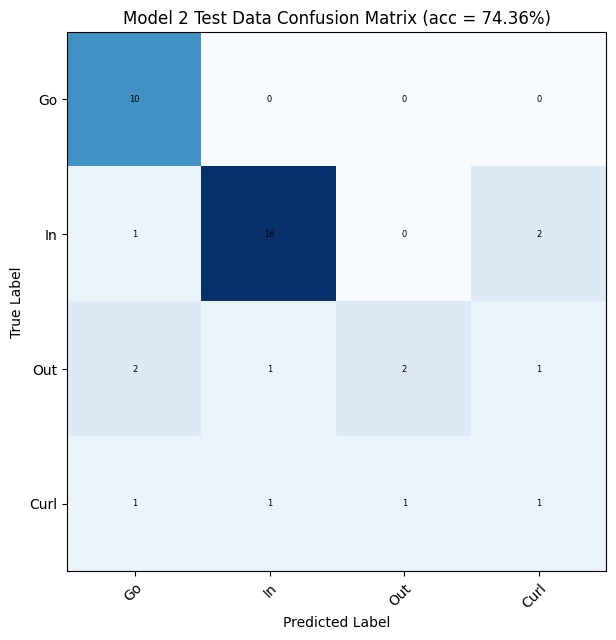

In [20]:
model2.load_state_dict(torch.load("models/model2.pt"))
model2.eval()

test_set = TensorDataset(X_test1, y_test1)
test_loader = DataLoader(test_set, batch_size=8, shuffle=False)

test_acc, test_loss, test_cm = TrainEval2.evaluate(model2, test_loader)

fig, ax = plt.subplots(1, 1, figsize = (14, 7))
TrainEval2.plot_confusion_mat(test_cm, ax, title = f"Model 2 Test Data Confusion Matrix (acc = {test_acc:.2%})")

model 3 was these features and these targets

talk about how adjusted everything to see what would be best parameters

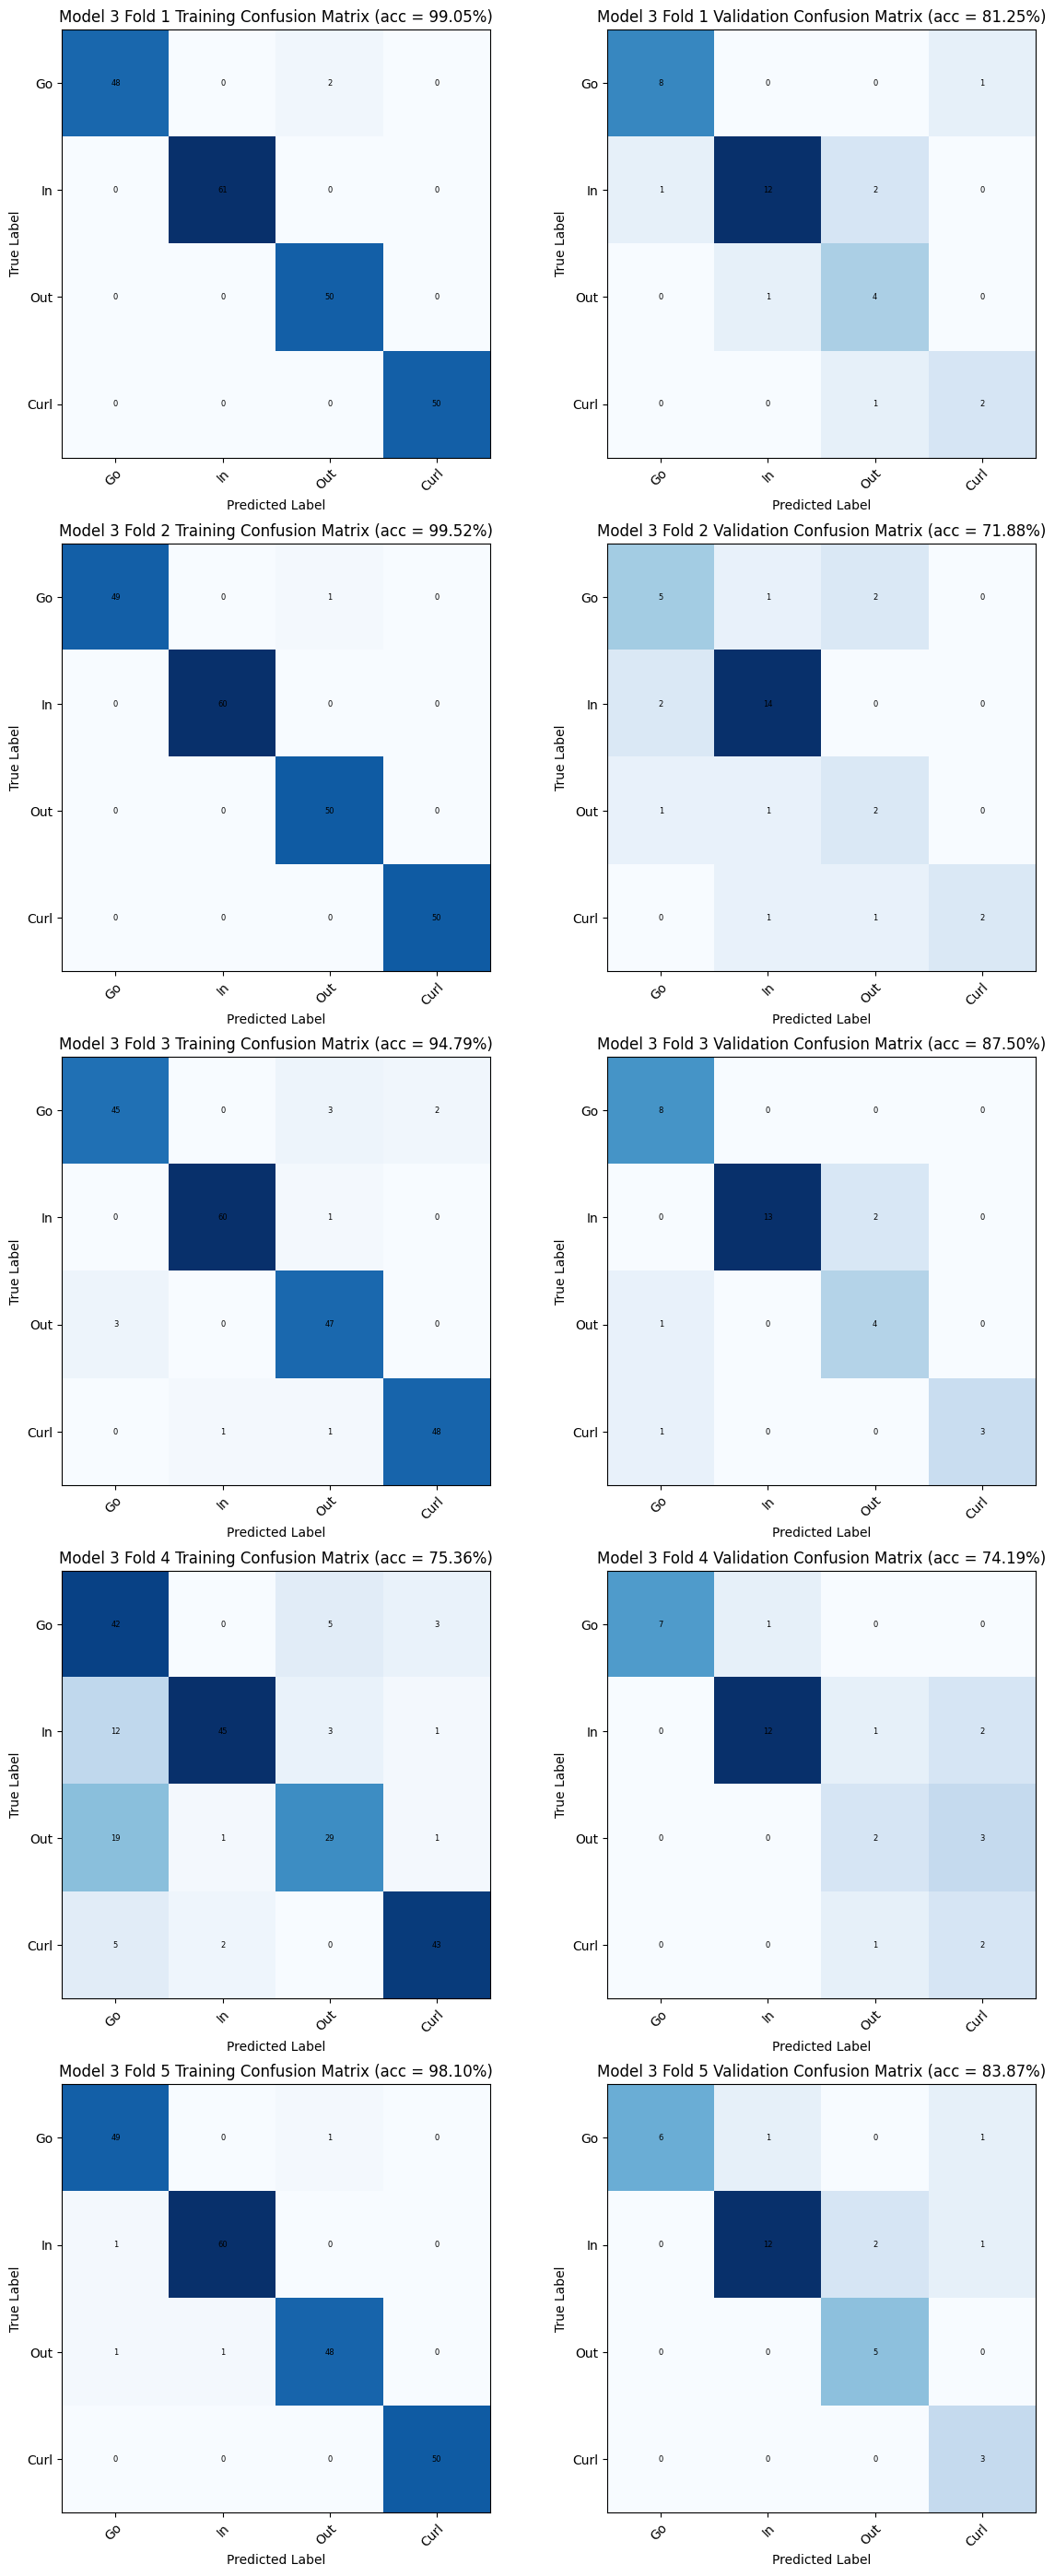

In [21]:
from src.RouteClassifier3 import RouteClassifier3
model3_cv_results = torch.load("models/model3_cv_results.pt")
train_acc  = model3_cv_results["train_acc"]
train_loss = model3_cv_results["train_loss"]
train_cm   = model3_cv_results["train_cm"]
val_acc    = model3_cv_results["val_acc"]
val_loss   = model3_cv_results["val_loss"]
val_cm     = model3_cv_results["val_cm"]

model3 = RouteClassifier3()
TrainEval3 = TrainEval(model3, second_labels=False)

fig, axarr = plt.subplots(5, 2, figsize = (14, 35))
ax = axarr[0][0]
TrainEval3.plot_confusion_mat(train_cm[0], ax, title = f"Model 3 Fold 1 Training Confusion Matrix (acc = {train_acc[0]:.2%})")
ax = axarr[0][1]
TrainEval3.plot_confusion_mat(val_cm[0], ax, title = f"Model 3 Fold 1 Validation Confusion Matrix (acc = {val_acc[0]:.2%})")

ax = axarr[1][0]
TrainEval3.plot_confusion_mat(train_cm[1], ax, title = f"Model 3 Fold 2 Training Confusion Matrix (acc = {train_acc[1]:.2%})")
ax = axarr[1][1]
TrainEval3.plot_confusion_mat(val_cm[1], ax, title = f"Model 3 Fold 2 Validation Confusion Matrix (acc = {val_acc[1]:.2%})")

ax = axarr[2][0]
TrainEval3.plot_confusion_mat(train_cm[2], ax, title = f"Model 3 Fold 3 Training Confusion Matrix (acc = {train_acc[2]:.2%})")
ax = axarr[2][1]
TrainEval3.plot_confusion_mat(val_cm[2], ax, title = f"Model 3 Fold 3 Validation Confusion Matrix (acc = {val_acc[2]:.2%})")

ax = axarr[3][0]
TrainEval3.plot_confusion_mat(train_cm[3], ax, title = f"Model 3 Fold 4 Training Confusion Matrix (acc = {train_acc[3]:.2%})")
ax = axarr[3][1]
TrainEval3.plot_confusion_mat(val_cm[3], ax, title = f"Model 3 Fold 4 Validation Confusion Matrix (acc = {val_acc[3]:.2%})")

ax = axarr[4][0]
TrainEval3.plot_confusion_mat(train_cm[4], ax, title = f"Model 3 Fold 5 Training Confusion Matrix (acc = {train_acc[4]:.2%})")
ax = axarr[4][1]
TrainEval3.plot_confusion_mat(val_cm[4], ax, title = f"Model 3 Fold 5 Validation Confusion Matrix (acc = {val_acc[4]:.2%})")

Then on test

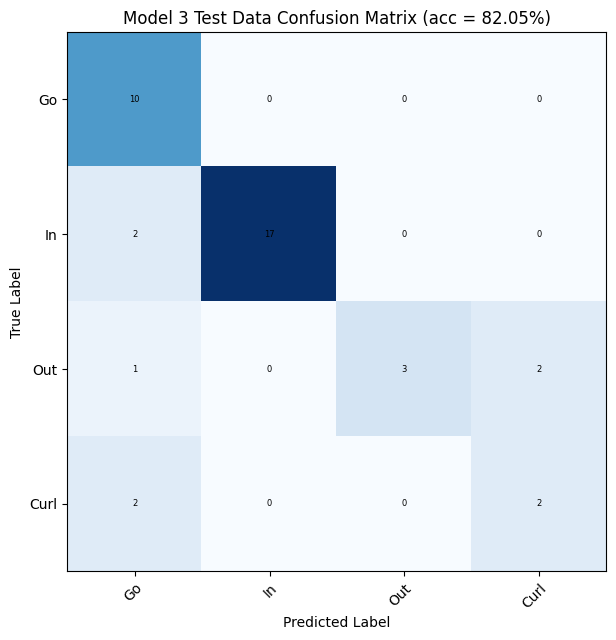

In [22]:
model3.load_state_dict(torch.load("models/model3.pt"))
model3.eval()

test_set = TensorDataset(X_test1, y_test1)
test_loader = DataLoader(test_set, batch_size=8, shuffle=False)

test_acc, test_loss, test_cm = TrainEval3.evaluate(model3, test_loader)

fig, ax = plt.subplots(1, 1, figsize = (14, 7))
TrainEval3.plot_confusion_mat(test_cm, ax, title = f"Model 3 Test Data Confusion Matrix (acc = {test_acc:.2%})")

model 4 was then second labels

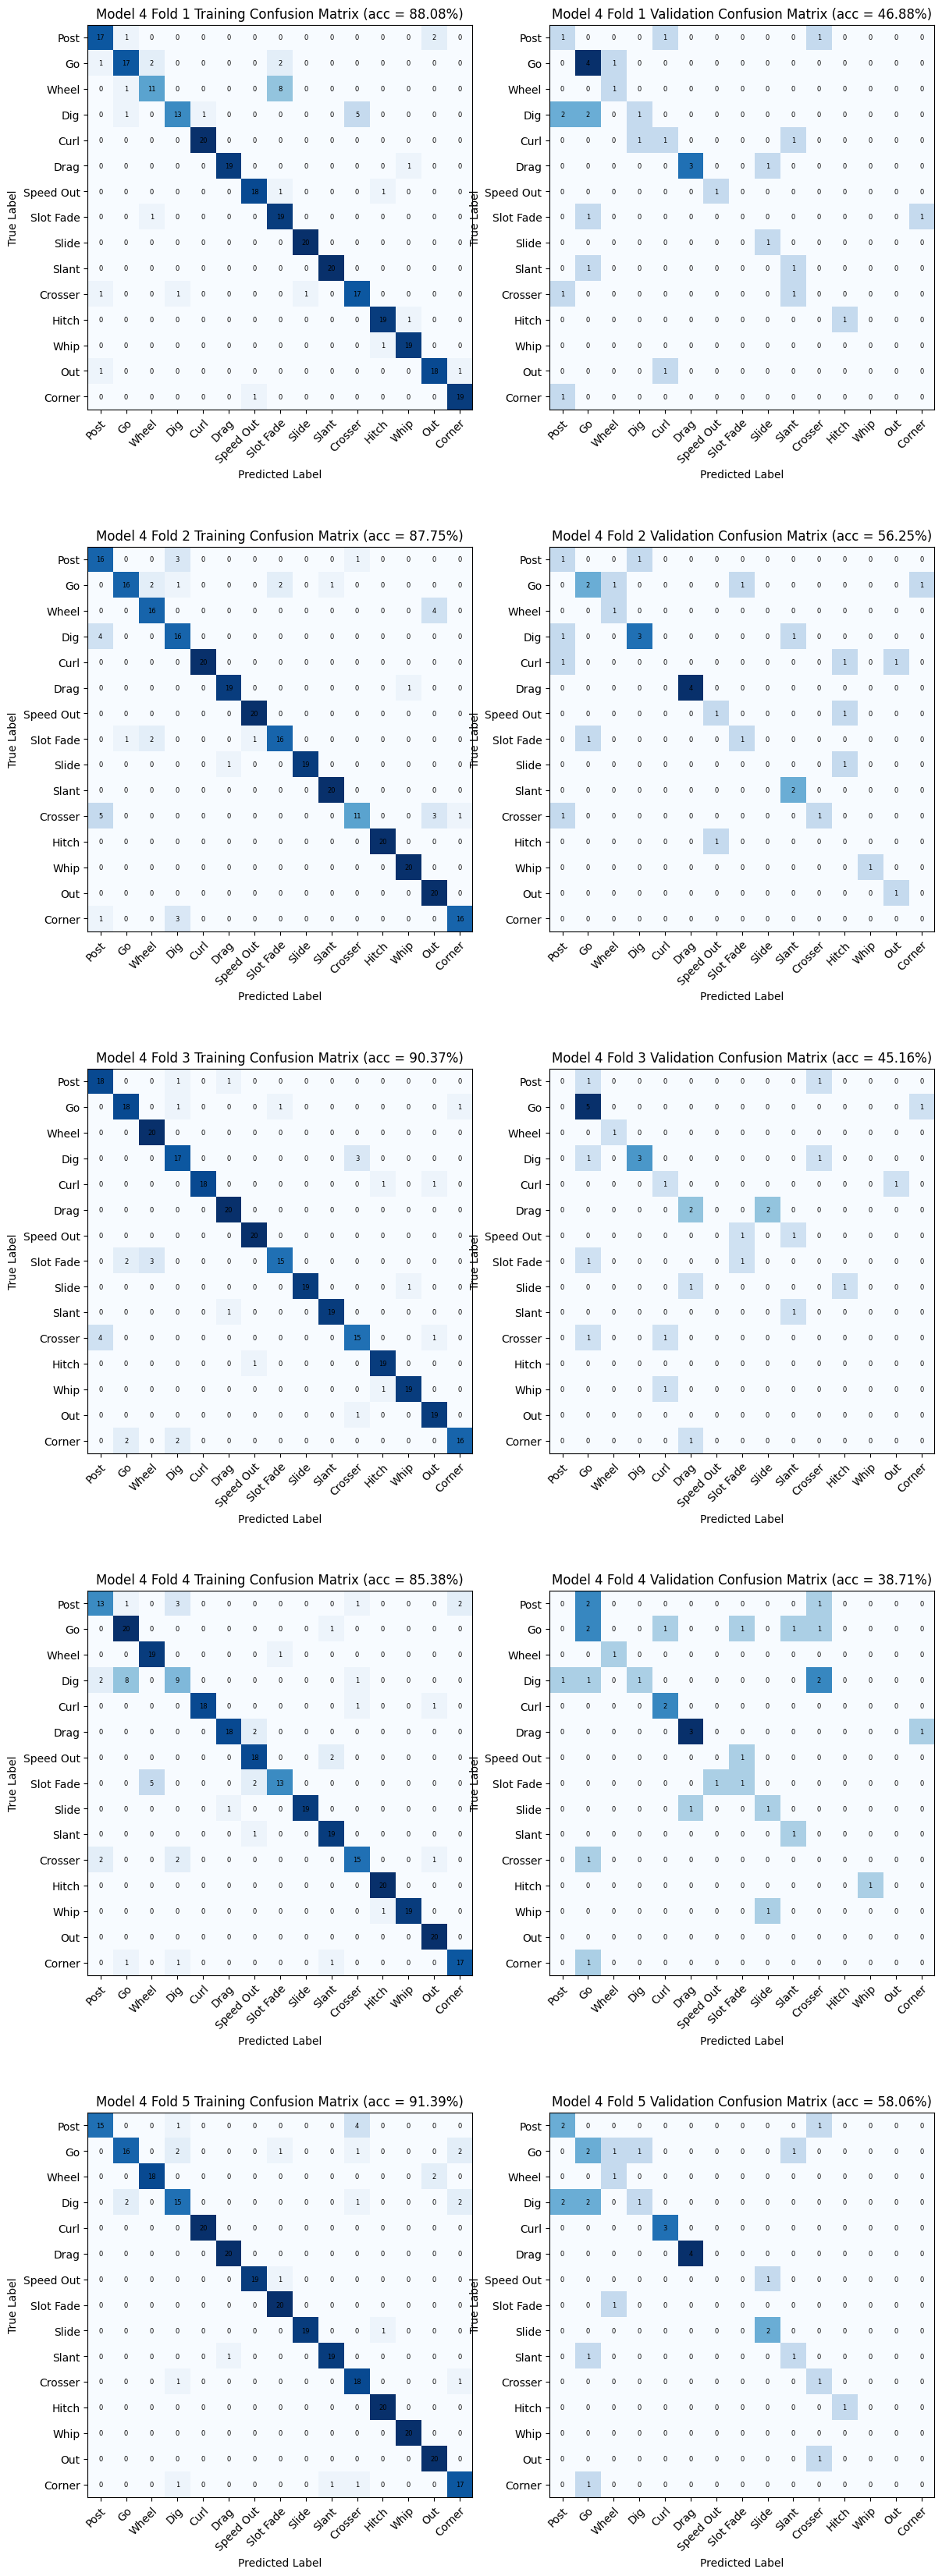

In [23]:
from src.RouteClassifier4 import RouteClassifier4
model4_cv_results = torch.load("models/model4_cv_results.pt")
train_acc  = model4_cv_results["train_acc"]
train_loss = model4_cv_results["train_loss"]
train_cm   = model4_cv_results["train_cm"]
val_acc    = model4_cv_results["val_acc"]
val_loss   = model4_cv_results["val_loss"]
val_cm     = model4_cv_results["val_cm"]

model4 = RouteClassifier4()
TrainEval4 = TrainEval(model4, second_labels=True)

fig, axarr = plt.subplots(5, 2, figsize = (14, 42))
ax = axarr[0][0]
TrainEval4.plot_confusion_mat(train_cm[0], ax, title = f"Model 4 Fold 1 Training Confusion Matrix (acc = {train_acc[0]:.2%})")
ax = axarr[0][1]
TrainEval4.plot_confusion_mat(val_cm[0], ax, title = f"Model 4 Fold 1 Validation Confusion Matrix (acc = {val_acc[0]:.2%})")

ax = axarr[1][0]
TrainEval4.plot_confusion_mat(train_cm[1], ax, title = f"Model 4 Fold 2 Training Confusion Matrix (acc = {train_acc[1]:.2%})")
ax = axarr[1][1]
TrainEval4.plot_confusion_mat(val_cm[1], ax, title = f"Model 4 Fold 2 Validation Confusion Matrix (acc = {val_acc[1]:.2%})")

ax = axarr[2][0]
TrainEval4.plot_confusion_mat(train_cm[2], ax, title = f"Model 4 Fold 3 Training Confusion Matrix (acc = {train_acc[2]:.2%})")
ax = axarr[2][1]
TrainEval4.plot_confusion_mat(val_cm[2], ax, title = f"Model 4 Fold 3 Validation Confusion Matrix (acc = {val_acc[2]:.2%})")

ax = axarr[3][0]
TrainEval4.plot_confusion_mat(train_cm[3], ax, title = f"Model 4 Fold 4 Training Confusion Matrix (acc = {train_acc[3]:.2%})")
ax = axarr[3][1]
TrainEval4.plot_confusion_mat(val_cm[3], ax, title = f"Model 4 Fold 4 Validation Confusion Matrix (acc = {val_acc[3]:.2%})")

ax = axarr[4][0]
TrainEval4.plot_confusion_mat(train_cm[4], ax, title = f"Model 4 Fold 5 Training Confusion Matrix (acc = {train_acc[4]:.2%})")
ax = axarr[4][1]
TrainEval4.plot_confusion_mat(val_cm[4], ax, title = f"Model 4 Fold 5 Validation Confusion Matrix (acc = {val_acc[4]:.2%})")

then on test

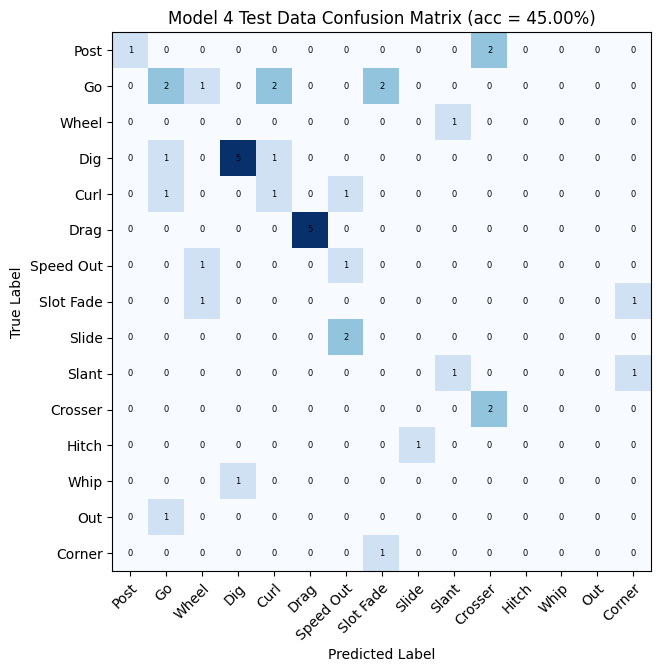

In [26]:
model4.load_state_dict(torch.load("models/model4.pt"))
model4.eval()

test_set = TensorDataset(X_test2, y_test2)
test_loader = DataLoader(test_set, batch_size=8, shuffle=False)

test_acc, test_loss, test_cm = TrainEval4.evaluate(model4, test_loader)

fig, ax = plt.subplots(1, 1, figsize = (14, 7))
TrainEval4.plot_confusion_mat(test_cm, ax, title = f"Model 4 Test Data Confusion Matrix (acc = {test_acc:.2%})")

## Conclusion
all models were above base rate by decent amount
not entirely, I thought I would've had higher accuracy on first set of labels
more data!! would probably be able to change model complexity in that case 